# Reproducible PBMC3K LOCAT PCA Analysis

This notebook is a cleaned duplicate of `pbmc_locat_PCA.ipynb` that:

- imports LOCAT from `/banach2/wes/locat-0.1`
- resets seeds before stochastic LOCAT steps
- reuses the original saved PBMC embedding so the UMAP matches the old notebook
- keeps the old `plot_grid` style for concentration-only vs concentration+depletion genes
        


In [2]:
!nvidia-smi

Wed Mar 11 14:40:51 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    Off  | 00000000:01:00.0 Off |                  Off |
| 30%   34C    P2    74W / 300W |    468MiB / 49140MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    Off  | 00000000:24:00.0 Off |                  Off |
| 30%   

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [4]:
from __future__ import annotations

import os
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
from IPython.display import display

LOCAT_SRC = Path("/banach2/wes/locat-0.1")
PBMC_EMBED_PATH = Path("/banach1/wes/LM_Sharing/data/pbmc3k_lognorm.h5ad")

if str(LOCAT_SRC) not in sys.path:
    sys.path.insert(0, str(LOCAT_SRC))

from locat.locat import LOCAT
import locat
import locat.locat as locat_impl


SEED = 13


def reset_seeds(seed: int = SEED) -> int:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    return seed


reset_seeds(SEED)
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, facecolor="white")
sns.set_context("talk")

print(f"locat version: {getattr(locat, '__version__', 'unknown')}")
print(f"Using LOCAT from: {Path(locat_impl.__file__).resolve()}")
assert str(Path(locat_impl.__file__).resolve()).startswith(str(LOCAT_SRC.resolve()))
assert PBMC_EMBED_PATH.exists(), PBMC_EMBED_PATH
        


locat version: 0.0.0-dev
Using LOCAT from: /banach2/wes/locat-0.1/locat/locat.py


## Load the original PBMC object and reuse its embedding

The UMAP/PCA geometry comes from the processed PBMC object at
`/banach1/wes/LM_Sharing/data/pbmc3k_processed.h5ad`.

For LOCAT training, the expression matrix is rebuilt from `.raw` so that genes absent from the processed var set can still be tested.
The expression matrix is then filtered to:

- remove pseudogene-style symbols such as `Gm*`, `*Rik`, `AC*`, `AA*`, and `Linc*`
- keep genes expressed in more than 1% of cells

This preserves the old embedding while avoiding the overly restrictive historical `var_names` subset.
        


In [5]:
reset_seeds(SEED)

adata_processed = sc.read_h5ad("/banach1/wes/LM_Sharing/data/pbmc3k_processed.h5ad")
adata = adata_processed.raw.to_adata()

pseudo_patterns = [
    r"^Gm\d+",
    r"Rik$",
    r"^AC\d+",
    r"^AA\d+",
    r"^A[0-9]{6,}",
    r"^Mir\d+",
    r"^Rpl\d*-\d+",
    r"^Rps\d*-\d+",
    r"^Linc",
]
pseudo_re = re.compile("|".join(f"(?:{p})" for p in pseudo_patterns))
is_pseudo = pd.Index(adata.var_names.astype(str)).to_series().str.match(pseudo_re)
adata = adata[:, ~is_pseudo.values].copy()

if sp.issparse(adata.X):
    n_cells_expressed = np.asarray((adata.X > 0).sum(axis=0)).ravel()
else:
    n_cells_expressed = (adata.X > 0).sum(axis=0)

keep = (n_cells_expressed / adata.n_obs) > 0.01
adata = adata[:, keep].copy()

# Reuse the original processed embedding/graph so plots match the historical notebook.
adata.obs = adata_processed.obs.copy()
adata.uns = adata_processed.uns.copy()
for key in adata_processed.obsm.keys():
    adata.obsm[key] = adata_processed.obsm[key].copy()
for key in adata_processed.obsp.keys():
    adata.obsp[key] = adata_processed.obsp[key].copy()

print(adata)
print("Available obsm keys:", list(adata.obsm.keys()))
print("Genes retained after raw-based filtering:", adata.n_vars)
adata
        


AnnData object with n_obs × n_vars = 2638 × 8859
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    obsp: 'distances', 'connectivities'
Available obsm keys: ['X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr']
Genes retained after raw-based filtering: 8859


/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 2638 × 8859
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    obsp: 'distances', 'connectivities'

## Fit LOCAT with the updated local source tree
        


In [18]:
reset_seeds(SEED)

w_transform = lambda x: np.clip(np.asarray(x), 0.0, np.inf)
embedding = adata.obsm["X_pca"].astype(np.float64)[:, :8]

def run_locat_scan(
    seed=SEED,
    rc_lambda_values= np.linspace(1.0, 2.0, 8),
    show_progress=True,
    n_bootstrap_inits=50,
):
    reset_seeds(seed)

    model = LOCAT(
        adata=adata,
        cell_embedding=embedding,
        k=20,
        n_bootstrap_inits=n_bootstrap_inits,
        show_progress=show_progress,
        knn=adata.obsp["connectivities"] if "connectivities" in adata.obsp else None,
        knn_mode="connectivity",
    )
    model._reg_covar = 1e-6

    results = model.gmm_scan(
        weights_transform=w_transform,
        max_freq=0.9,
        include_depletion_scan=True,
        rc_lambda_values=rc_lambda_values,
    )
    return model, results


m, sres = run_locat_scan()
        


2026-03-11 15:02:56.256 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-11 15:02:56.256 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 51 cells: 100%|███████████████████████████████████| 30/30 [00:01<00:00, 24.80it/s]
2026-03-11 15:02:57.922 | INFO     | locat.locat:background_pdf:439 - Using 5 components
fitting background: 100%|████████████████████████████████████████████| 10/10 [00:00<00:00, 59.17it/s]
null distribution parameters (perm. pseudo-genes):   0%|                       | 0/7 [00:00<?, ?it/s]2026-03-11 15:02:58.315 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-11 15:02:58.316 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [00:10<00:00,  1.56s/it]
scanning genes: 100%|████████████████████████████████████████████| 8859/8859 [02:22<00:00, 62.08

In [19]:
def extract_max_deficit(scan):
    if not isinstance(scan, dict):
        return np.nan
    rows = scan.get("per_lambda")
    if not rows:
        p0 = scan.get("p0_abs")
        obs = scan.get("obs_prop")
        return (p0 - obs) if (p0 is not None and obs is not None) else np.nan
    deficits = [
        float(row["p0_abs"]) - float(row["obs_prop"])
        for row in rows
        if row.get("p0_abs") is not None and row.get("obs_prop") is not None
    ]
    return max(deficits) if deficits else np.nan


def build_locat_df(results):
    df = pd.DataFrame({gene: res._asdict() for gene, res in results.items()}).T
    df.index.name = "gene"

    # Compatibility aliases so old notebook logic still reads naturally.
    df["localization_pval"] = df["depletion_pval"]
    df["p_final"] = df["pval"]
    df["max_deficit"] = df["depletion_scan"].map(extract_max_deficit)
    df["is_conc_sig"] = df["concentration_pval"] < 0.05
    df["is_depl_sig"] = df["depletion_pval"] < 0.05
    df["is_joint_sig"] = df["pval"] < 0.05

    df = df.sort_values(
        ["pval", "concentration_pval", "depletion_pval"],
        ascending=[True, True, True],
    )
    return df


locat_df = build_locat_df(sres)

summary = pd.Series(
    {
        "genes_scored": int(locat_df.shape[0]),
        "conc_sig": int(locat_df["is_conc_sig"].sum()),
        "depl_sig": int(locat_df["is_depl_sig"].sum()),
        "joint_sig": int(locat_df["is_joint_sig"].sum()),
        "conc_only": int((locat_df["is_conc_sig"] & ~locat_df["is_depl_sig"]).sum()),
        "conc_depl": int((locat_df["is_conc_sig"] & locat_df["is_depl_sig"]).sum()),
    }
)

save_path = Path("PBMC_locat_df_locat01_repro.pkl")
locat_df.to_pickle(save_path)

display(summary.to_frame("value"))
print(f"Saved results to {save_path.resolve()}")
locat_df.head(10)
        


,value
genes_scored,8754
conc_sig,1827
depl_sig,8657
joint_sig,548
conc_only,66
conc_depl,1761


Saved results to /banach2/wes/Locat-paper-repro-private/notebooks/figures/FigS1_3kPBMC/PBMC_locat_df_locat01_repro.pkl


,gene_name,bic,zscore,sens_score,depletion_pval,concentration_pval,h_size,h_sens,pval,K_components,sample_size,depletion_scan,localization_pval,p_final,max_deficit,is_conc_sig,is_depl_sig,is_joint_sig
gene,,,,,,,,,,,,,,,,,,
RNASE2,RNASE2,5.9579,7.328457,1.0,0.0,0.0,0.016529,0.0,0.000826,2,59.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.000826,0.991961,True,True,True
RP5-887A10.1,RP5-887A10.1,-3208566051.172291,3.904195,1.0,0.0,0.000047,0.027396,0.0,0.00137,2,35.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.00137,0.980100,True,True,True
ICAM4,ICAM4,8.699026,3.790885,1.0,0.0,0.000075,0.027396,0.0,0.00137,2,35.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.00137,0.969510,True,True,True
BACE2,BACE2,-5889761859.259194,3.591428,1.0,0.0,0.000164,0.028983,0.0,0.001449,2,33.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.001449,0.980948,True,True,True
RP11-428G5.5,RP11-428G5.5,-11592630.901236,3.46296,1.0,0.0,0.000267,0.030767,0.0,0.001538,2,31.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.001538,0.983796,True,True,True
MYOF,MYOF,9.55608,3.367864,1.0,0.0,0.000379,0.030767,0.0,0.001538,2,31.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.001538,0.994927,True,True,True
FXYD6,FXYD6,9.660164,3.364742,1.0,0.0,0.000383,0.030767,0.0,0.001538,2,31.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.001538,0.993377,True,True,True
OSBPL10,OSBPL10,8.539526,3.326886,1.0,0.0,0.000439,0.031743,0.0,0.001587,2,30.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.001587,0.972077,True,True,True
ARHGEF10L,ARHGEF10L,10.056512,3.044539,1.0,0.0,0.001165,0.032784,0.0,0.001639,2,29.0,"{'p_value': 1e-12, 'raw_min_p': 1e-12, 'log_p_...",0.0,0.001639,0.993925,True,True,True


## Plot helpers
        


In [31]:
def get_gene_x(adata, gene, layer=None):
    x = adata[:, gene].X if layer is None else adata[:, gene].layers[layer]
    if sp.issparse(x):
        x = x.toarray().ravel()
    else:
        x = np.asarray(x).ravel()
    return x


def plot_gene_umap_expressing_on_top(
    adata,
    gene,
    ax,
    expr_thresh=0.0,
    q_vmax=80,
    layer=None,
    s_bg=5,
    s_expr=8,
    alpha_bg=0.6,
    alpha_expr=0.9,
    use_log1p=True,
    cmap_genes="Reds",
    title_fs=12,
):
    X = adata.obsm["X_umap"]
    x = get_gene_x(adata, gene, layer=layer)

    if use_log1p:
        x_plot = np.log1p(np.clip(x, 0, None))
        thresh = np.log1p(expr_thresh)
    else:
        x_plot = np.clip(x, 0, None)
        thresh = expr_thresh

    expr = x_plot > thresh
    ax.scatter(X[:, 0], X[:, 1], c="gray", s=s_bg, alpha=alpha_bg, linewidths=0)

    xe = x_plot[expr]
    vmax = np.percentile(xe, q_vmax) if xe.size > 0 else 1.0
    ax.scatter(
        X[expr, 0],
        X[expr, 1],
        c=np.clip(xe, 0, vmax),
        s=s_expr,
        alpha=alpha_expr,
        cmap=cmap_genes,
        vmin=0,
        vmax=vmax,
        linewidths=0,
    )

    ax.set_title(gene, fontsize=title_fs, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    return vmax


def plot_grid(
    adata,
    genes_top,
    genes_bottom,
    title_top="Conc-only",
    title_bottom="Conc + depleted",
    expr_thresh=0.0,
    use_log1p=True,
):
    n = max(len(genes_top), len(genes_bottom))
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5), squeeze=False)

    for row, genes, row_title in [(0, genes_top, title_top), (1, genes_bottom, title_bottom)]:
        for i in range(n):
            ax = axes[row, i]
            if i >= len(genes):
                ax.axis("off")
                continue
            plot_gene_umap_expressing_on_top(
                adata,
                genes[i],
                ax,
                expr_thresh=expr_thresh,
                q_vmax=80,
                s_expr=8,
                use_log1p=use_log1p,
                cmap_genes="Reds",
            )
        axes[row, 0].set_ylabel(row_title, fontsize=11)

    plt.tight_layout()
    plt.show()
    return fig
        


## Top concentration-only and concentration+depletion genes
        


In [21]:
alpha = 0.05

conc_only = locat_df[
    (locat_df["concentration_pval"] < alpha) &
    (locat_df["depletion_pval"] >= alpha)
].copy()

conc_depl = locat_df[
    (locat_df["concentration_pval"] < alpha) &
    (locat_df["depletion_pval"] < alpha)
].copy()

conc_only_sorted = conc_only.sort_values(
    ["zscore", "max_deficit", "concentration_pval"],
    ascending=[False, False, True],
)
conc_depl_sorted = conc_depl.sort_values(
    ["max_deficit", "depletion_pval", "concentration_pval"],
    ascending=[False, True, True],
)

genes_conc_only = conc_only_sorted.head(6).index.tolist()
genes_conc_depl = conc_depl_sorted.head(6).index.tolist()

print("Top conc-only genes:", genes_conc_only)
print("Top conc+depl genes:", genes_conc_depl)

display(
    conc_only_sorted.head(6)[
        ["pval", "concentration_pval", "depletion_pval", "zscore", "max_deficit", "sample_size"]
    ]
)
display(
    conc_depl_sorted.head(6)[
        ["pval", "concentration_pval", "depletion_pval", "zscore", "max_deficit", "sample_size"]
    ]
)
        


Top conc-only genes: ['IL7R', 'CXCR4', 'LCK', 'MAL', 'CD27', 'PRKCQ-AS1']
Top conc+depl genes: ['VMO1', 'MYOF', 'TNNT1', 'ARHGEF10L', 'FXYD6', 'RNASE2']


,pval,concentration_pval,depletion_pval,zscore,max_deficit,sample_size
gene,,,,,,
IL7R,0.039141,0.0,0.269713,12.4369,0.073749,1062.0
CXCR4,0.085354,0.0,0.05628,10.344442,0.120904,1585.0
LCK,0.520361,0.0,1.0,10.005871,-0.038012,953.0
MAL,0.509248,0.0,1.0,9.787817,-0.013983,353.0
CD27,0.513899,0.0,1.0,9.176478,-0.151020,632.0
PRKCQ-AS1,0.51529,0.0,1.0,8.890096,-0.117591,445.0


,pval,concentration_pval,depletion_pval,zscore,max_deficit,sample_size
gene,,,,,,
VMO1,0.00577,0.000841,0.0,3.141256,0.998259,29.0
MYOF,0.001538,0.000379,0.0,3.367864,0.994927,31.0
TNNT1,0.005237,0.000883,0.0,3.126928,0.994738,32.0
ARHGEF10L,0.001639,0.001165,0.0,3.044539,0.993925,29.0
FXYD6,0.001538,0.000383,0.0,3.364742,0.993377,31.0
RNASE2,0.000826,0.0,0.0,7.328457,0.991961,59.0


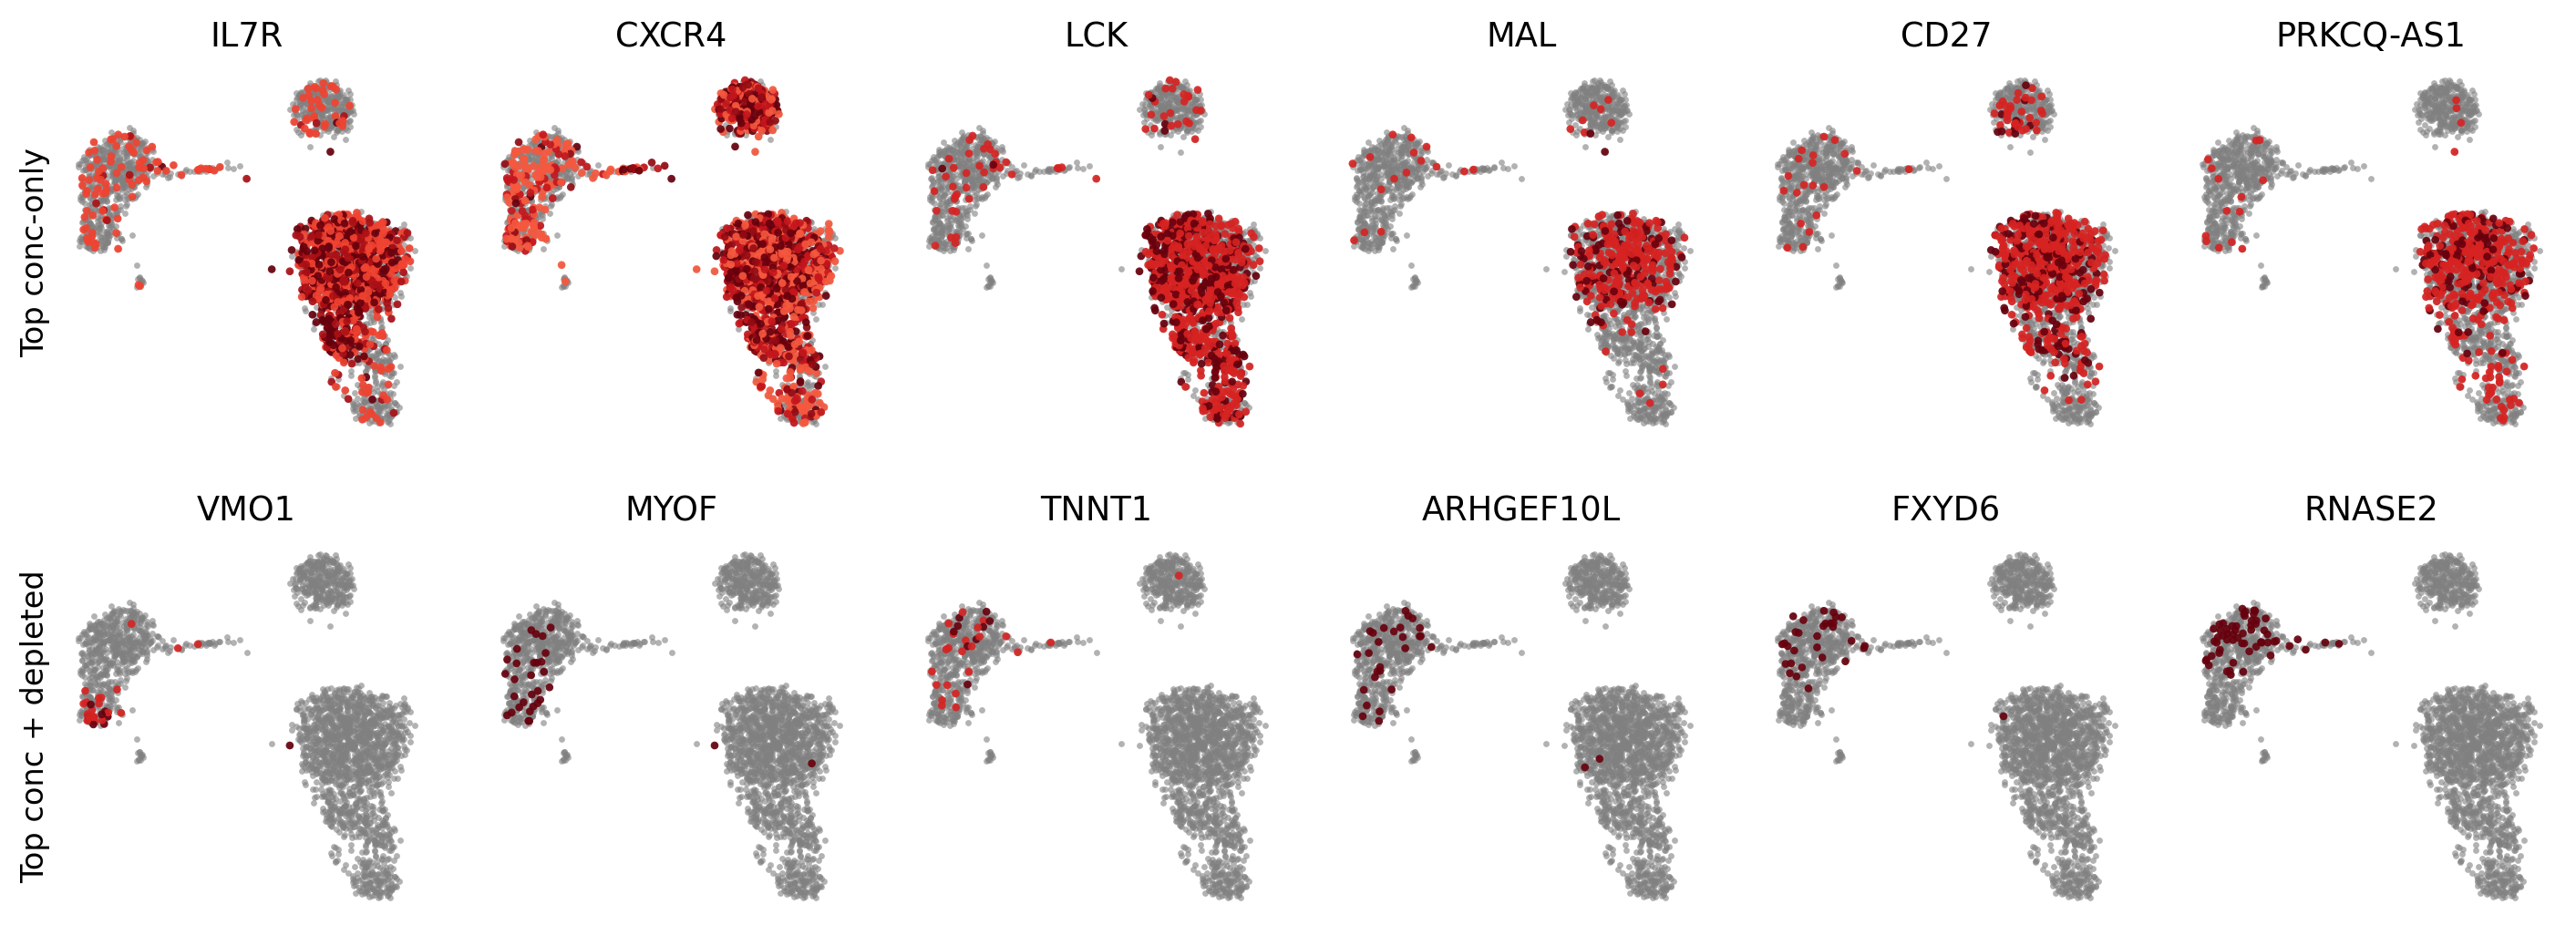

In [32]:
fig = plot_grid(
    adata,
    genes_conc_only,
    genes_conc_depl,
    title_top="Top conc-only",
    title_bottom="Top conc + depleted",
    expr_thresh=0.0,
    use_log1p=True,
)
        
fig.savefig(
    "manual_gene_plot_grid.svg",
    format="svg",
    bbox_inches="tight",
)